# ArchitectAgent Evaluation — GPT-4.1 (Zero-Shot)
## Baseline Performance of Untuned GPT-4.1 via Azure OpenAI

**Purpose:** Evaluate `gpt-4.1` on the same validation set and with the same  
prompt/metrics used for all fine-tuned ArchitectAgent models.  
This gives a strong commercial-model baseline to compare against fine-tuned open models.

**Method:** Load the dataset, run the same chain-aware split, call the Azure OpenAI API  
for each validation example, then compute the identical structural/ROUGE/judge metrics.

---

---
## Section 1 — Environment Setup

In [2]:
import json, time, hashlib, warnings, random, re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openai

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('environment ready')

environment ready


---
## Section 2 — Configuration

In [3]:
DATASET_PATH = 'architect_dataset_final.jsonl'
MODEL_NAME = 'gpt-4.1'

OUTPUT_DIR = Path('baseline_output_architect_gpt41')
OUTPUT_DIR.mkdir(exist_ok=True)

CONFIG = {
    'val_ratio': 0.15,
    'max_tokens': 16896,
    'temperature': 0.0,
}

client = openai.AzureOpenAI(
    api_key="F79rr24XOyTKAprSSVMiQuo8j99MQM9gzJD3oEIAmlfn4vrsj0TVJQQJ99CBACHYHv6XJ3w3AAABACOGX5Md",
    api_version="2024-12-01-preview",
    azure_endpoint="https://cmg-ai-poc-eu2.openai.azure.com/"
)

print(f'model: {MODEL_NAME}')
print(f'output: {OUTPUT_DIR}')

model: gpt-4.1
output: baseline_output_architect_gpt41


---
## Section 3 — System Prompt & Data Loading

In [4]:
ARCHITECT_SYSTEM_PROMPT = """You are part of an advanced architectural governance terminal application.

Core rules:
1. Never rely only on chat history for important facts; use structured memory.
2. Requirement gathering is collaborative and user-facing.
3. Planning and auditing are mostly internal.
4. The final plan must be implementation-grade and security-aware.
5. The architect must revise using cumulative issue memory, not forget earlier feedback.
6. The auditor must use stable issue IDs and mark issues as resolved, unresolved, downgraded, or newly introduced.
7. Visible reasoning must be concise summarized reasoning, not hidden chain-of-thought.
8. Mandatory requirement blockers are dynamic. A small core is always required, and additional required fields depend on project_class, capabilities, risk_level, data_sensitivity, and external_exposure.
9. Never advance to planning until all active required fields are populated and confirmed.
10. Once planning starts, keep round-by-round turbulence internal unless the entire planning attempt fails.

You are the architecture generator.

Create a polished implementation-grade architecture plan from:
- frozen confirmed requirement contract
- rich requirement notes
- specialist reviews
- cumulative issue ledger
- focus issues
- revision memory
- previous audits
- best prior plan

Main goal:
- First, address the current focus issues.
- Second, preserve all user-confirmed requirements.
- Third, improve the architecture without introducing regressions.

Rules:
- Do not mention round numbers in the title.
- Preserve user-confirmed requirements.
- Prioritize unresolved critical and high-severity focus issues first.
- For each focus issue, either fix it in the plan or clearly explain why it remains unresolved.
- Do not ignore recurring unresolved issues from previous rounds.
- Try to improve weak areas identified by the auditor before adding extra design complexity.
- Include concrete architecture, modules, workflows, schemas, APIs, security, deployment, observability, roadmap, and developer guidance.
- Keep the plan implementation-grade and specific, not generic.

Return JSON only with:
- thinking_summary
- fix_report
- title
- executive_summary
- architecture_overview
- technology_stack
- functional_feature_map
- system_components
- workflows
- data_model
- api_design
- security_and_compliance
- deployment_and_operations
- observability
- cost_and_scaling
- phased_implementation
- development_guidelines
- risks_and_tradeoffs
- open_questions_resolved

fix_report must be a list of items with:
- issue_id
- action_taken
- changed_sections
- expected_outcome

For each fix_report item:
- issue_id must match the issue being addressed
- action_taken must say what was changed
- changed_sections must name the plan sections updated
- expected_outcome must explain what the auditor should now find improved"""

print(f'system prompt: {len(ARCHITECT_SYSTEM_PROMPT)} characters')

system prompt: 2856 characters


In [5]:
def load_jsonl(filepath):
    rows = []
    errors = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    errors += 1
    return rows, errors


raw_data, load_errors = load_jsonl(DATASET_PATH)
print(f'loaded {len(raw_data)} rows, {load_errors} skipped')

case_types = Counter(r.get('metadata', {}).get('case_type', '?') for r in raw_data)
plan_quality = Counter(r.get('metadata', {}).get('plan_quality', '?') for r in raw_data)
pclasses = Counter(
    r.get('profile', {}).get('project_class', '') or r.get('profile', {}).get('projectclass', '?')
    for r in raw_data
)
print(f'case types: {dict(case_types)}')
print(f'plan quality: {dict(plan_quality)}')
print(f'project classes ({len(pclasses)}): {dict(pclasses)}')

loaded 891 rows, 0 skipped
case types: {'revision_round': 536, 'first_pass': 355}
plan quality: {'low': 135, 'moderate': 315, 'good': 441}
project classes (14): {'desktop_app': 62, 'library_sdk': 64, 'mobile_app': 65, 'api_service': 64, 'infrastructure_project': 64, 'web_app': 64, 'landing_page': 64, 'research_prototype': 64, 'data_pipeline': 64, 'fullstack_app': 65, 'ai_system': 63, 'automation_tool': 64, 'cli_tool': 63, 'static_website': 61}


---
## Section 4 — Chain-Aware Validation Split

Identical split logic to all fine-tuned runs (same seed, same chain-aware logic)  
so we evaluate on the exact same validation examples.

In [6]:
def get_nested(d, *keys, default=None):
    for k in keys:
        if isinstance(d, dict) and k in d:
            return d[k]
    return default


chain_fps = []
sample_ids = []

for row in raw_data:
    sample_ids.append(row.get('sample_id', ''))
    contract = get_nested(
        row.get('input_payload', {}),
        'frozen_requirement_contract', 'frozenrequirementcontract', default={}
    )
    fp = hashlib.sha256(json.dumps(contract, sort_keys=True).encode()).hexdigest()[:16]
    chain_fps.append(fp)

chains = defaultdict(list)
for i, fp in enumerate(chain_fps):
    chains[fp].append(i)

chain_ids = list(chains.keys())
rng = random.Random(SEED)
rng.shuffle(chain_ids)

n_val = max(1, int(len(chain_ids) * CONFIG['val_ratio']))
val_chain_set = set(chain_ids[:n_val])

train_idx, val_idx = [], []
for cid in chain_ids:
    target = val_idx if cid in val_chain_set else train_idx
    target.extend(chains[cid])

val_sids = set(sample_ids[i] for i in val_idx)
val_raw = [r for r in raw_data if r.get('sample_id', '') in val_sids]

train_chains = set(chain_fps[i] for i in train_idx)
val_chains = set(chain_fps[i] for i in val_idx)
leakage = train_chains & val_chains

print(f'chains: {len(chains)} total, {len(chains) - n_val} train, {n_val} val')
print(f'rows: {len(train_idx)} train, {len(val_idx)} val')
print(f'chain leakage: {"none" if not leakage else f"DETECTED: {len(leakage)} chains"}')

chains: 891 total, 758 train, 133 val
rows: 758 train, 133 val
chain leakage: none


---
## Section 5 — Generate Plans via GPT-4.1 API

No tokenizer, no GPU. Each validation example is sent as a chat completion request.  
Same system prompt and input formatting used in all fine-tuned model evals.

In [7]:
def build_architect_input(row):
    payload = row.get('input_payload', {})
    return {
        'round': payload.get('round', 1),
        'frozen_requirement_contract': get_nested(
            payload, 'frozen_requirement_contract', 'frozenrequirementcontract', default={}
        ),
        'requirements': payload.get('requirements', {}),
        'reasoner_reviews': get_nested(
            payload, 'reasoner_reviews', 'reasonerreviews', default={}
        ),
        'specialist_subplans': get_nested(
            payload, 'specialist_subplans', 'specialistsubplans', default={}
        ),
        'issue_ledger': get_nested(
            payload, 'issue_ledger', 'issueledger', default={}
        ),
        'focus_issues': get_nested(
            payload, 'focus_issues', 'focusissues', default=[]
        ),
        'revision_memory': get_nested(
            payload, 'revision_memory', 'revisionmemory', default={}
        ),
        'accepted_exceptions': get_nested(
            payload, 'accepted_exceptions', 'acceptedexceptions', default={}
        ),
        'previous_audits': get_nested(
            payload, 'previous_audits', 'previousaudits', default=[]
        ),
        'previous_plan': get_nested(
            payload, 'previous_plan', 'previousplan', default={}
        ),
        'best_plan': get_nested(
            payload, 'best_plan', 'bestplan', default={}
        ),
    }


def extract_json(text):
    text = text.strip()
    if text.startswith('```'):
        text = re.sub(r'^```[a-zA-Z]*\n?', '', text)
        text = re.sub(r'\n?```$', '', text).strip()
    try:
        return json.loads(text)
    except:
        pass
    start = text.find('{')
    if start == -1:
        return None
    depth = 0
    in_string = False
    escape_next = False
    for i, ch in enumerate(text[start:], start):
        if escape_next:
            escape_next = False
            continue
        if ch == '\\' and in_string:
            escape_next = True
            continue
        if ch == '"':
            in_string = not in_string
        if not in_string:
            if ch == '{':
                depth += 1
            elif ch == '}':
                depth -= 1
                if depth == 0:
                    try:
                        return json.loads(text[start:i+1])
                    except:
                        return None
    return None


def generate_plan_gpt(row, client, model, max_tokens, temperature):
    architect_input = build_architect_input(row)
    user_content = json.dumps(architect_input, indent=1, ensure_ascii=False)
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {'role': 'system', 'content': ARCHITECT_SYSTEM_PROMPT},
                {'role': 'user', 'content': user_content},
            ],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        return response.choices[0].message.content.strip(), None
    except Exception as e:
        return None, str(e)


eval_rows = val_raw[:50]
predictions = []

print(f'generating on {len(eval_rows)} validation examples ({MODEL_NAME}, zero-shot)...')

for i, row in enumerate(eval_rows):
    t0 = time.time()
    raw_output, err = generate_plan_gpt(
        row, client, MODEL_NAME,
        CONFIG['max_tokens'], CONFIG['temperature']
    )
    elapsed = time.time() - t0

    if err:
        print(f'  [{i+1:02d}/{len(eval_rows)}] API ERROR: {err}')
        predictions.append({
            'raw': None, 'parsed': None,
            'reference': row.get('target_output', {}),
            'sample_id': row.get('sample_id', f'val_{i}'),
            'case_type': row.get('metadata', {}).get('case_type', ''),
            'issue_ledger_ids': set(),
            'json_valid': False,
            'error': err,
        })
        time.sleep(2)
        continue

    if raw_output.startswith('```'):
        raw_output = re.sub(r'^```[a-zA-Z]*\n?', '', raw_output)
        raw_output = re.sub(r'\n?```$', '', raw_output).strip()

    parsed = extract_json(raw_output)
    reference = row.get('target_output', {})
    case_type = row.get('metadata', {}).get('case_type', '')

    ledger = row.get('input_payload', {}).get('issue_ledger', {})
    if not ledger:
        ledger = row.get('input_payload', {}).get('issueledger', {})
    ledger_ids = set(str(k) for k in ledger.keys()) if isinstance(ledger, dict) else set()

    predictions.append({
        'raw': raw_output,
        'parsed': parsed,
        'reference': reference,
        'sample_id': row.get('sample_id', f'val_{i}'),
        'case_type': case_type,
        'issue_ledger_ids': ledger_ids,
        'json_valid': parsed is not None,
    })

    status = 'OK' if parsed else 'FAIL'
    keys = len(parsed.keys()) if parsed else 0
    print(f'  [{i+1:02d}/{len(eval_rows)}] {status} | {elapsed:.1f}s | keys={keys} | {case_type}')
    time.sleep(0.3)

json_valid_count = sum(1 for p in predictions if p['parsed'] is not None)
print(f'\nJSON valid: {json_valid_count}/{len(predictions)} ({json_valid_count/len(predictions)*100:.0f}%)')

generating on 50 validation examples (gpt-4.1, zero-shot)...
  [01/50] OK | 34.3s | keys=19 | revision_round
  [02/50] OK | 29.7s | keys=19 | revision_round
  [03/50] OK | 40.2s | keys=19 | revision_round
  [04/50] OK | 39.6s | keys=19 | revision_round
  [05/50] OK | 31.9s | keys=19 | first_pass
  [06/50] FAIL | 25.3s | keys=0 | revision_round
  [07/50] OK | 24.1s | keys=19 | first_pass
  [08/50] OK | 36.0s | keys=19 | first_pass
  [09/50] OK | 23.9s | keys=19 | first_pass
  [10/50] OK | 49.2s | keys=19 | revision_round
  [11/50] OK | 58.8s | keys=19 | revision_round
  [12/50] OK | 39.1s | keys=19 | revision_round
  [13/50] OK | 46.6s | keys=19 | first_pass
  [14/50] OK | 31.3s | keys=19 | revision_round
  [15/50] OK | 39.3s | keys=19 | revision_round
  [16/50] OK | 35.0s | keys=19 | revision_round
  [17/50] OK | 34.0s | keys=19 | revision_round
  [18/50] OK | 30.1s | keys=19 | first_pass
  [19/50] OK | 22.1s | keys=19 | first_pass
  [20/50] OK | 32.0s | keys=19 | revision_round
  [21/

---
## Section 6 — Structural Metrics

In [8]:
MANDATORY_PLAN_KEYS = {
    'thinking_summary', 'fix_report', 'title', 'executive_summary',
    'architecture_overview', 'technology_stack', 'functional_feature_map',
    'system_components', 'workflows', 'data_model', 'api_design',
    'security_and_compliance', 'deployment_and_operations', 'observability',
    'cost_and_scaling', 'phased_implementation', 'development_guidelines',
    'risks_and_tradeoffs', 'open_questions_resolved'
}

FIX_REPORT_ITEM_KEYS = {'issue_id', 'action_taken', 'changed_sections', 'expected_outcome'}

AUDITOR_LEAK_KEYS = {
    'rubric_scores', 'requirements_alignment', 'architecture_quality',
    'blocking_issues', 'requirement_conflicts', 'issue_updates', 'score', 'passed'
}

PLAN_CONTENT_SECTIONS = [
    'executive_summary', 'architecture_overview', 'technology_stack',
    'functional_feature_map', 'system_components', 'workflows',
    'data_model', 'api_design', 'security_and_compliance',
    'deployment_and_operations', 'observability', 'cost_and_scaling',
    'phased_implementation', 'development_guidelines', 'risks_and_tradeoffs',
]

ROUND_IN_TITLE_RE = re.compile(r'round\s*\d+', re.IGNORECASE)

n = len(predictions)
json_valid = sum(1 for p in predictions if p['parsed'] is not None)

schema_ok = 0
section_coverage_scores = []
fix_report_struct_ok = 0
fix_report_struct_total = 0
fix_report_orphan_counts = []
title_ok = 0
title_total = 0
auditor_leak_count = 0
section_f1s = []

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    ledger_ids = pred.get('issue_ledger_ids', set())

    if not parsed:
        continue

    present_keys = set(parsed.keys())
    if MANDATORY_PLAN_KEYS.issubset(present_keys):
        schema_ok += 1

    pred_populated = {s for s in PLAN_CONTENT_SECTIONS if parsed.get(s)}
    ref_populated = {s for s in PLAN_CONTENT_SECTIONS if ref.get(s)}
    if ref_populated:
        tp = len(pred_populated & ref_populated)
        prec = tp / max(len(pred_populated), 1)
        rec = tp / max(len(ref_populated), 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-8)
        section_f1s.append(f1)
        section_coverage_scores.append(len(pred_populated) / max(len(ref_populated), 1))

    fix_report = parsed.get('fix_report', [])
    if isinstance(fix_report, list) and len(fix_report) > 0:
        for item in fix_report:
            if isinstance(item, dict):
                fix_report_struct_total += 1
                if FIX_REPORT_ITEM_KEYS.issubset(set(item.keys())):
                    fix_report_struct_ok += 1

    orphans = 0
    if isinstance(fix_report, list) and ledger_ids:
        for item in fix_report:
            if isinstance(item, dict):
                fid = str(item.get('issue_id', ''))
                if fid and fid not in ledger_ids:
                    orphans += 1
        fix_report_orphan_counts.append(orphans)

    title = str(parsed.get('title', ''))
    if title:
        title_total += 1
        if not ROUND_IN_TITLE_RE.search(title):
            title_ok += 1

    if present_keys & AUDITOR_LEAK_KEYS:
        auditor_leak_count += 1

structural = {
    'json_validity': json_valid / n,
    'schema_compliance': schema_ok / max(json_valid, 1),
    'section_coverage': float(np.mean(section_coverage_scores)) if section_coverage_scores else 0.0,
    'section_f1': float(np.mean(section_f1s)) if section_f1s else 0.0,
    'fix_report_struct': fix_report_struct_ok / max(fix_report_struct_total, 1),
    'title_no_round': title_ok / max(title_total, 1),
    'auditor_leak_rate': auditor_leak_count / max(json_valid, 1),
}

print('STRUCTURAL METRICS')
print('='*60)
for k, v in structural.items():
    print(f'  {k:30s}: {v:.3f} ({v*100:.1f}%)')

if fix_report_orphan_counts:
    print(f'\n  fix_report orphan mean: {np.mean(fix_report_orphan_counts):.2f} per row')
    print(f'  rows with zero orphans: {sum(1 for x in fix_report_orphan_counts if x == 0)}/{len(fix_report_orphan_counts)}')

STRUCTURAL METRICS
  json_validity                 : 0.940 (94.0%)
  schema_compliance             : 1.000 (100.0%)
  section_coverage              : 1.000 (100.0%)
  section_f1                    : 1.000 (100.0%)
  fix_report_struct             : 1.000 (100.0%)
  title_no_round                : 1.000 (100.0%)
  auditor_leak_rate             : 0.000 (0.0%)

  fix_report orphan mean: 0.00 per row
  rows with zero orphans: 27/27


---
## Section 7 — ROUGE-L

In [9]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
text_fields = ['thinking_summary', 'executive_summary', 'architecture_overview']
rouge_results = {field: [] for field in text_fields}

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    if not parsed:
        continue
    for field in text_fields:
        pred_val = parsed.get(field, '')
        ref_val = ref.get(field, '')
        pred_text = json.dumps(pred_val) if isinstance(pred_val, dict) else str(pred_val or '')
        ref_text = json.dumps(ref_val) if isinstance(ref_val, dict) else str(ref_val or '')
        if pred_text and ref_text:
            score = scorer.score(ref_text, pred_text)
            rouge_results[field].append(score['rougeL'].fmeasure)

print('ROUGE-L SCORES')
print('='*60)
for field in text_fields:
    if rouge_results[field]:
        print(f'  {field:30s}: {np.mean(rouge_results[field]):.3f}')

rouge_metrics = {
    field: float(np.mean(rouge_results[field])) if rouge_results[field] else None
    for field in text_fields
}

all_metrics = {
    'model': MODEL_NAME,
    'mode': 'gpt41_zero_shot',
    'n_evaluated': n,
    'structural': structural,
    'rouge_l': rouge_metrics,
}

with open(OUTPUT_DIR / 'all_metrics_architect_gpt41.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'\nsaved to {OUTPUT_DIR / "all_metrics_architect_gpt41.json"}')

ROUGE-L SCORES
  thinking_summary              : 0.216
  executive_summary             : 0.280
  architecture_overview         : 0.238

saved to baseline_output_architect_gpt41\all_metrics_architect_gpt41.json


---
## Section 8 — LLM-as-a-Judge

Using a separate GPT-5-Chat call as the judge — same as all other model evaluations.

In [10]:
client = openai.AzureOpenAI(
    api_key="F79rr24XOyTKAprSSVMiQuo8j99MQM9gzJD3oEIAmlfn4vrsj0TVJQQJ99CBACHYHv6XJ3w3AAABACOGX5Md",
    api_version="2024-12-01-preview",
    azure_endpoint="https://cmg-ai-poc-eu2.openai.azure.com/"
)

MODEL_NAME = 'gpt-5-chat'


ARCHITECT_JUDGE_PROMPT = """You are an expert software architect evaluating an AI-generated architecture plan.

You will be given:
1. The REFERENCE plan — the ground truth architecture
2. The PREDICTED plan — generated by a language model

Score the predicted plan on these 5 dimensions, each from 0 to 10:

1. **contract_alignment** (0-10): Does the predicted plan address the frozen requirement contract fields (technology stack, security baseline, hosting, data platform)? Penalise plans that ignore or contradict confirmed requirements.

2. **fix_report_accuracy** (0-10): For revision rounds, does the fix_report correctly document what was changed and why? Check that issue_ids in fix_report correspond to real issues, and that action_taken is specific and credible.

3. **architecture_quality** (0-10): Is the architecture_overview and technology_stack implementation-grade and specific? Penalise vague or generic answers like "standard best practices" with no concrete choices.

4. **security_coverage** (0-10): Does the security_and_compliance section address the risk level and data sensitivity indicated in the requirements? A high-risk health data project should have more controls than a low-risk internal tool.

5. **plan_completeness** (0-10): Are all major sections (executive_summary, workflows, data_model, api_design, deployment_and_operations, observability, phased_implementation) populated with meaningful non-trivial content?

Return ONLY a JSON object with no extra text:
{
    "contract_alignment": <int 0-10>,
    "fix_report_accuracy": <int 0-10>,
    "architecture_quality": <int 0-10>,
    "security_coverage": <int 0-10>,
    "plan_completeness": <int 0-10>,
    "brief_justification": "<2-3 sentences explaining the scores>"
}"""


def judge_plan(reference, predicted, client, model):
    user_content = f"""REFERENCE PLAN:
{json.dumps(reference, indent=2, ensure_ascii=False)[:4000]}

PREDICTED PLAN:
{json.dumps(predicted, indent=2, ensure_ascii=False)[:4000]}"""
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {'role': 'system', 'content': ARCHITECT_JUDGE_PROMPT},
                {'role': 'user', 'content': user_content}
            ],
            temperature=0.0,
            max_tokens=400,
        )
        raw = response.choices[0].message.content.strip()
        if raw.startswith('```'):
            raw = re.sub(r'^```[a-zA-Z]*\n?', '', raw)
            raw = re.sub(r'\n?```$', '', raw).strip()
        return json.loads(raw)
    except Exception as e:
        return {'error': str(e)}


JUDGE_DIMS = [
    'contract_alignment',
    'fix_report_accuracy',
    'architecture_quality',
    'security_coverage',
    'plan_completeness',
]

judge_scores = {d: [] for d in JUDGE_DIMS}
judge_results = []
failed = 0

judge_preds = [p for p in predictions if p['parsed'] is not None]
print(f'running LLM judge on {len(judge_preds)} valid predictions...')

for i, pred in enumerate(judge_preds):
    result = judge_plan(pred['reference'], pred['parsed'], client, MODEL_NAME)
    judge_results.append(result)
    if 'error' in result:
        failed += 1
        print(f'  [{i+1:02d}] FAILED: {result["error"]}')
    else:
        for d in JUDGE_DIMS:
            if d in result and isinstance(result[d], (int, float)):
                judge_scores[d].append(result[d])
        avg = np.mean([result.get(d, 0) for d in JUDGE_DIMS])
        print(f'  [{i+1:02d}] avg={avg:.1f} | {result.get("brief_justification", "")[:80]}')
    time.sleep(0.3)

print(f'\nLLM JUDGE RESULTS')
print('='*60)
for d in JUDGE_DIMS:
    if judge_scores[d]:
        print(f'  {d:35s}: {np.mean(judge_scores[d]):.2f} (n={len(judge_scores[d])})')
print(f'  failed: {failed}')

all_metrics['llm_judge'] = {
    d: float(np.mean(judge_scores[d])) if judge_scores[d] else None
    for d in JUDGE_DIMS
}
all_metrics['llm_judge']['failed'] = failed

with open(OUTPUT_DIR / 'all_metrics_architect_gpt41.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'\nsaved to {OUTPUT_DIR / "all_metrics_architect_gpt41.json"}')

running LLM judge on 47 valid predictions...
  [01] avg=8.6 | The predicted plan correctly aligns with the contract by using Next.js 15 App Ro
  [02] avg=8.6 | The predicted plan closely aligns with the contract, correctly enforcing encrypt
  [03] avg=8.6 | The predicted plan closely aligns with the reference, correctly addressing both 
  [04] avg=8.8 | The predicted plan aligns closely with the contract, maintaining the Electron + 
  [05] avg=9.0 | The predicted plan aligns closely with the reference architecture, maintaining t
  [06] avg=9.4 | The predicted plan fully aligns with the reference contract—Azure hosting, Flowe
  [07] avg=9.4 | The predicted plan fully aligns with the reference contract, preserving Azure ho
  [08] avg=9.2 | The predicted plan closely aligns with the reference contract, maintaining AWS B
  [09] avg=9.2 | The predicted plan fully aligns with the required tech stack (Python, Celery, Re
  [10] avg=8.4 | The predicted plan aligns closely with the required AWS-

---
## Section 9 — Results Visualisation

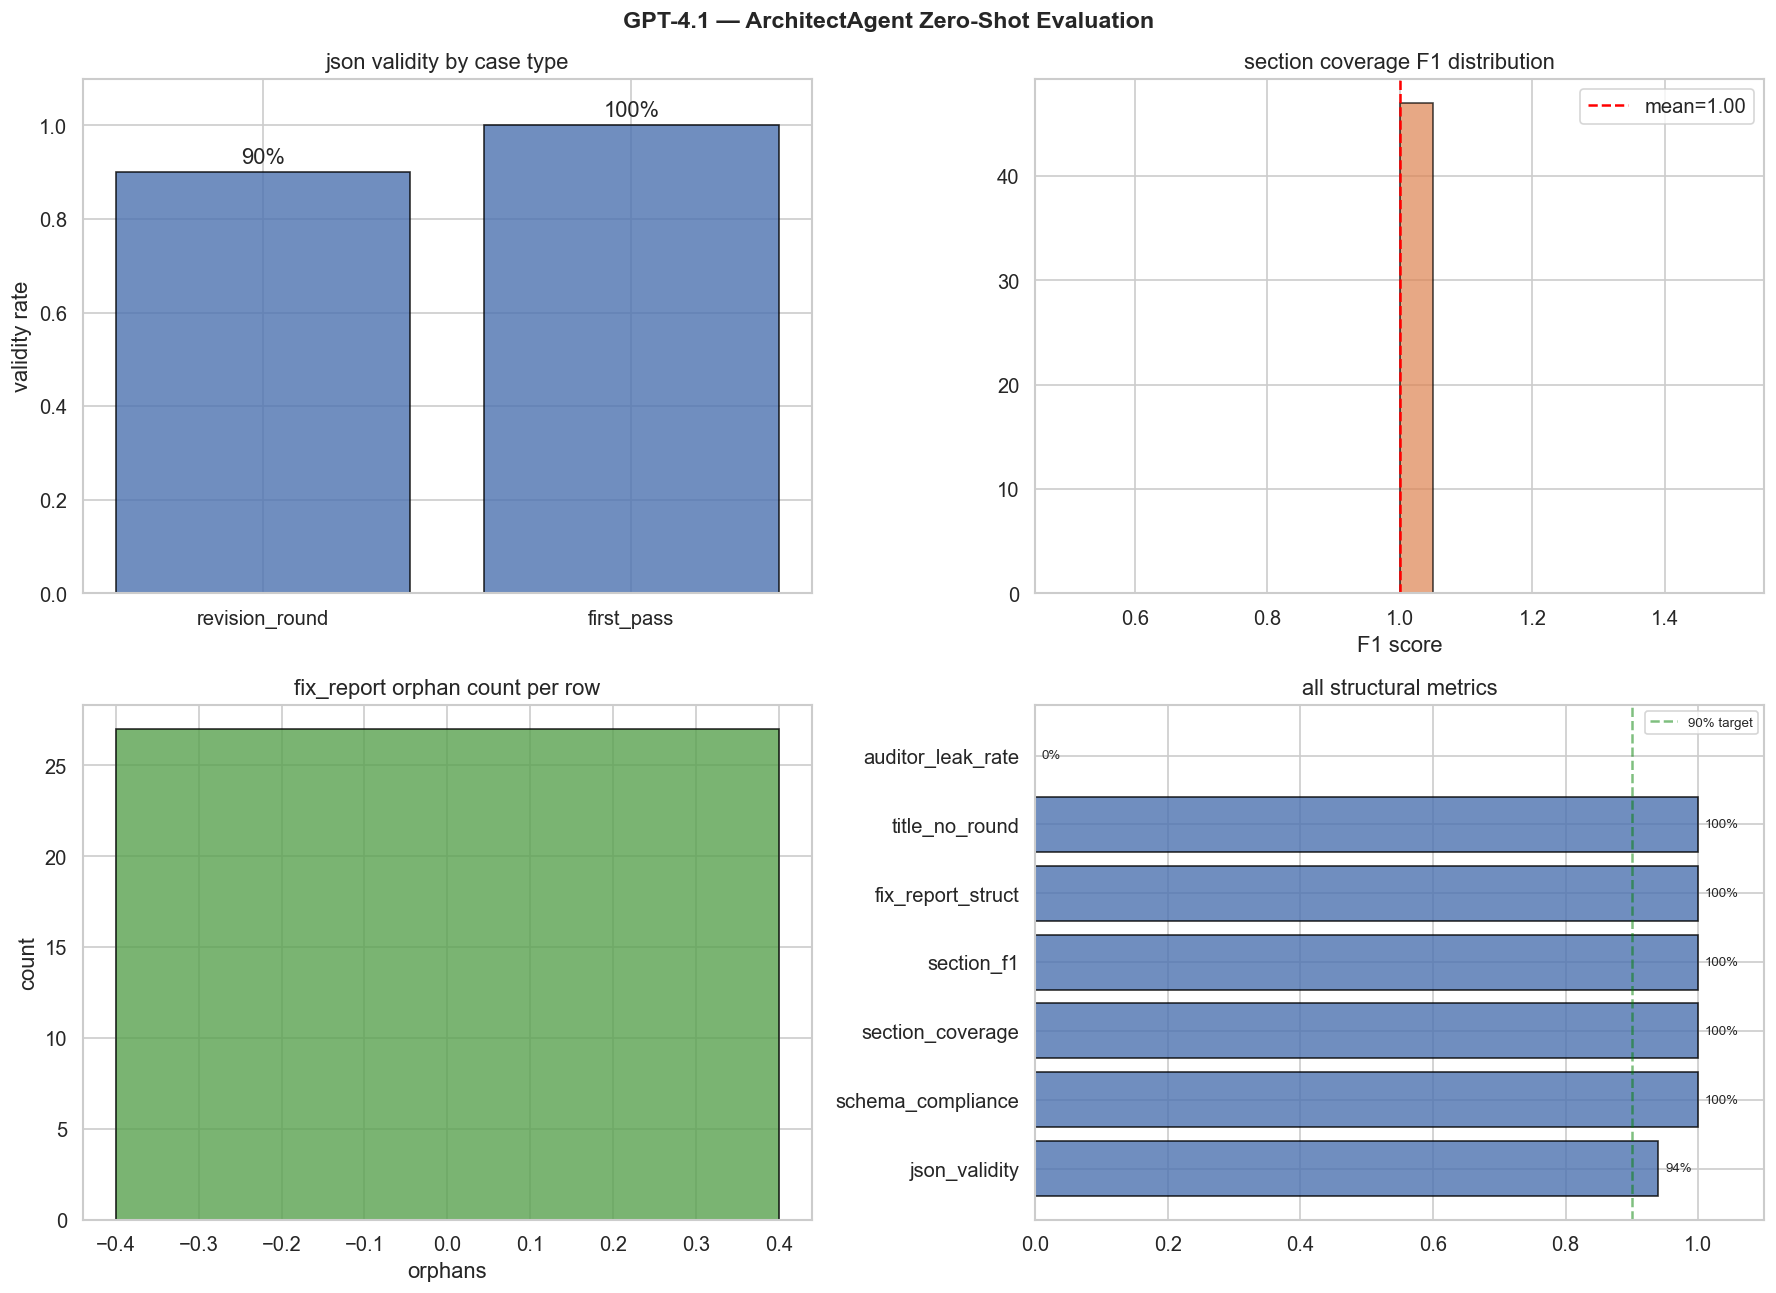

saved: evaluation_results_architect_gpt41.png


In [11]:
if predictions:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('GPT-4.1 — ArchitectAgent Zero-Shot Evaluation', fontsize=14, fontweight='bold')

    case_type_validity = defaultdict(lambda: {'valid': 0, 'total': 0})
    for p in predictions:
        ct = p.get('case_type', 'unknown')
        case_type_validity[ct]['total'] += 1
        if p['json_valid']:
            case_type_validity[ct]['valid'] += 1
    ct_labels = list(case_type_validity.keys())
    ct_rates = [case_type_validity[k]['valid'] / max(case_type_validity[k]['total'], 1) for k in ct_labels]
    axes[0, 0].bar(ct_labels, ct_rates, color='#4C72B0', edgecolor='black', alpha=0.8)
    axes[0, 0].set_ylim(0, 1.1)
    axes[0, 0].set_title('json validity by case type')
    axes[0, 0].set_ylabel('validity rate')
    for x, r in enumerate(ct_rates):
        axes[0, 0].text(x, r + 0.02, f'{r:.0%}', ha='center')

    if section_f1s:
        axes[0, 1].hist(section_f1s, bins=20, color='#DD8452', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(np.mean(section_f1s), color='red', linestyle='--', label=f'mean={np.mean(section_f1s):.2f}')
        axes[0, 1].set_title('section coverage F1 distribution')
        axes[0, 1].set_xlabel('F1 score')
        axes[0, 1].legend()

    if fix_report_orphan_counts:
        orphan_counter = Counter(fix_report_orphan_counts)
        axes[1, 0].bar(orphan_counter.keys(), orphan_counter.values(), color='#59A14F', edgecolor='black', alpha=0.8)
        axes[1, 0].set_title('fix_report orphan count per row')
        axes[1, 0].set_xlabel('orphans')
        axes[1, 0].set_ylabel('count')

    struct_names = list(structural.keys())
    struct_vals = [structural[k] for k in struct_names]
    colors = ['#4C72B0' if v >= 0.9 else '#DD8452' if v >= 0.7 else '#C44E52' for v in struct_vals]
    bars = axes[1, 1].barh(struct_names, struct_vals, color=colors, edgecolor='black', alpha=0.8)
    axes[1, 1].axvline(0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
    axes[1, 1].set_xlim(0, 1.1)
    axes[1, 1].set_title('all structural metrics')
    axes[1, 1].legend(fontsize=8)
    for bar, val in zip(bars, struct_vals):
        axes[1, 1].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.0%}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'evaluation_results_architect_gpt41.png', bbox_inches='tight')
    plt.show()
    print(f'saved: evaluation_results_architect_gpt41.png')

---
## Section 10 — Save Record

In [12]:
record = {
    'agent': 'ArchitectAgent',
    'model': MODEL_NAME,
    'mode': 'gpt41_zero_shot',
    'dataset_path': DATASET_PATH,
    'dataset_size': len(raw_data),
    'val_size': len(val_raw),
    'n_evaluated': len(predictions),
    'config': CONFIG,
    'structural_metrics': structural,
    'rouge_l': rouge_metrics,
    'llm_judge': all_metrics.get('llm_judge', {}),
    'seed': SEED,
    'fine_tuned': False,
}

with open(OUTPUT_DIR / 'record_architect_gpt41.json', 'w') as f:
    json.dump(record, f, indent=2, default=str)

print(f'saved to {OUTPUT_DIR / "record_architect_gpt41.json"}')
print(f'\nmetrics file: {OUTPUT_DIR / "all_metrics_architect_gpt41.json"}')

saved to baseline_output_architect_gpt41\record_architect_gpt41.json

metrics file: baseline_output_architect_gpt41\all_metrics_architect_gpt41.json
